## Overview

This tutorial reproduces the ground truth benchmark from our
[paper](https://doi.org/10.1038/s41467-026-71607-5): a dataset of MDA-MB-231 cells
carrying **8 lentiviral clones**, profiled with the
[MAESTER](https://doi.org/10.1038/s41587-022-01210-8) protocol. Because the clonal
labels are known independently of the mitochondrial signal, they provide a
ground truth against which MT-SNV-based inference can be scored.

We will:

1. Pre-process the Allele Frequency Matrix (cell and variant filtering, genotyping)
2. Compute cell-cell distances in MT-SNV space and quantify how well they separate the ground truth clones
3. Infer a mitochondrial phylogeny and its clones
4. Score the inference against the lentiviral labels (ARI, NMI)

If you are new to MiTo, start from the
[Getting Started](getting_started.ipynb) tutorial instead: it walks through the same
workflow without the benchmarking detail.

**N.B.** a working MiTo installation is a prerequisite. See the
[installation guide](https://mito.readthedocs.io/en/latest/installation.html).


## Dataset
This tutorial starts by downloding our test dataset from zenodo. Here, we will download the `MDA_clones` benchmarking dataset introduced in our recent [pre-print](https://doi.org/10.1101/2025.06.17.660165). This is a tri-modal dataset including simoultaneous profiling of MT-SNVs, gene expression, and lentiviral barcodes (i.e., our ground truth clonal labels) for n=558 quality controlled cells.

In [ ]:
# Set WD
WD='.'  # Change this to your working directory
!cd $WD

# Download and unzip test data
!wget https://zenodo.org/records/17225334/files/data_test.tar.gz && \
tar -xzvf data_test.tar.gz && \
rm data_test.tar.gz 

The `MDA_clones` dataset we have just downloaded includes:

1. `afm_unfiltered.h5ad`: unfiltered AFM (the output from nf-MiTo PREPROCESS, with `--pp_method` = `maegatk`)
2. `cells_meta.csv`: cell metadata, including minimal QC covariates and ground truth clonal labels (`GBC` column)
3. `coverage.txt.gz`: cell-by-MT-genome-position coverage table

In [2]:
!ls data_test

afm_unfiltered.h5ad  coverage.txt.gz  source_data.tar.gz
cells_meta.csv	     source_data


## Setup environment
We would also need to import all the necessary code, and to set up logging/visualization parameters:

In [3]:
import os
import logging
import numpy as np
import scanpy as sc
import mito as mt
import matplotlib.pyplot as plt
import plotting_utils as plu

# Logging
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

# Plotting parameters 
plu.set_rcParams({'figure.dpi':80})

# MiTo version and working directory
print(f"MiTo version: {mt.__version__}")
print(f"Working directory: {os.getcwd()}")

MiTo version: 0.3.0
Working directory: /Users/cossa/Desktop/projects/MiTo


## Load the Allelic Frequency Matrix (AFM)

We can now load our unfiltered AFM:


In [4]:
afm = sc.read('data_test/afm_unfiltered.h5ad')

# The file was written by an earlier MiTo: bring it to the current object contract
mt.io.migrate_afm(afm)

print(afm)
print(f'scLT system: {afm.uns["scLT_system"]}')
print(f'Pre-processing pipeline adopted: {afm.uns["pp_method"]}')

2026-09-21 10:09:08,888 - INFO - Migrate AFM: site_coverage -> DP (dense), qual -> var["quality"]


AnnData object with n_obs × n_vars = 558 × 18846
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered'
    var: 'pos', 'ref', 'alt', 'quality'
    uns: 'pp_method', 'scLT_system'
    layers: 'AD', 'DP', None (.X)


scLT system: MAESTER
Pre-processing pipeline adopted: maegatk


As we can see, our `afm` is an `AnnData` object equipped with the following slots:

* `.obs`: cell metadata, with minimal QC covariates and ground truth clonal labels (i.e., `GBC` column) from lentiviral barcoding
* `.var`: variant (MT-SNVs) metadata: position, reference and alternative allele, and the mean base call quality
* `.uns`: dataset parameters (i.e., `scLT_system` and `pp_method`), to which each MiTo step appends what it did, under `mito`
* `.layers`: two parallel cell x variant matrices

At this stage, `afm.layers` includes:

* `AD`: alternative allele total UMI counts
* `DP`: total UMI counts at the variant's site, defined for **every** cell, so that a covered cell with no alternative read is distinguishable from an uncovered one

and `.X` holds the allele frequencies, `AD / DP`.

In [5]:
# Selection of cells (n=2, rows) and variants (n=3, columns) with most non-zero AF values
cells = (afm.X>0).sum(axis=1).A1.argsort()[::-1][:2]
variants = (afm.X>0).sum(axis=0).A1.argsort()[::-1][:3]

# Print out each layer subsection
print('AF')
print(afm[cells, variants].X.toarray())
print('AD')
print(afm[cells, variants].layers['AD'].toarray())
print('DP')
print(afm[cells, variants].layers['DP'])
print('base quality (per variant)')
print(afm.var['quality'].iloc[variants].values)

AF
[[1.        0.9994376 1.       ]
 [1.        1.        1.       ]]
AD
[[3043 1777 1859]
 [2962 1446 2492]]
DP
[[3043 1778 1859]
 [2962 1446 2492]]
base quality (per variant)
[44.99266055 44.99082569 44.99815838]


We can now proceed with AFM pre-processing.

## AFM pre-processing
Proper AFM pre-processing is crucial for robust lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165)), and MiTo provides highly-optimized methods to handle this important analysis step.

### Cell Filtering
As mentioned, cells in the unfiltered AFM have already passed standard Gene Expression QC. However, we still need make sure that only cells with an high-quality MT-SNVs profile are included in downstream analysis. Specifically, here we are looking for cells with sufficiently high and evenly distributed coverage across the entire MT-genome (or MAESTER target sites, ~13k sites across the ~16kB MT-genome). To perform cell filtering, MiTo implements the `mt.pp.filter_cells` function:

In [6]:
mt.pp.filter_cells(afm, cell_filter='filter2')
afm_raw = afm.copy()  # Keep a copy of the AFM with all MT-SNVs, for visualization purposes

2026-09-21 10:09:09,035 - INFO - scLT system: MAESTER


2026-09-21 10:09:09,047 - INFO - Filtered cells (median target site coverage >=25, covered sites >=0.75): 375


As we can see, the number of cells dropped from 558 to 375 (i.e., 37% of the starting cells were filtered out because they did not satisfy the necessary quality standards).

### MT-SNVs filtering
We can now proceed with next step: MT-SNVs filtering. To do this, we will use the `mt.pp.filter_afm` function:

In [7]:
mt.pp.filter_afm(afm)

2026-09-21 10:09:09,142 - INFO - Filter AFM: MAESTER / maegatk, n cells=375, n MT-SNVs=18494


2026-09-21 10:09:09,142 - INFO - Restrict to MT-gene bodies: True


2026-09-21 10:09:09,184 - INFO - quality filter: n cells=375, n MT-SNVs=4375


2026-09-21 10:09:09,184 - INFO - Re-annotate variants in afm


2026-09-21 10:09:09,204 - INFO - candidate filter: n cells=375, n MT-SNVs=72


...

2026-09-21 10:09:10,001 - INFO - Re-annotate variants in afm


2026-09-21 10:09:10,003 - INFO - Use the genotypes in the bin layer.


2026-09-21 10:09:10,003 - INFO - Compute distances: ncores=8, metric=weighted_jaccard.


2026-09-21 10:09:10,007 - INFO - Final afm: n cells=276, n characters=24


2026-09-21 10:09:10,007 - INFO - AFM filtering complete: 0.94 s


As we can see from the printed logs, `mt.pp.filter_afm` performs different tasks to ensure only high-quality MT-SNVs (and the respective variant-bearing cells) are included for lineage inference (see our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods).

In [8]:
print(afm)

AnnData object with n_obs × n_vars = 276 × 24
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered', 'n_characters', 'n_imputed'
    var: 'pos', 'ref', 'alt', 'quality', 'error_rate', 'n_carriers', 'n_imputed', 'prevalence', 'snr', 'mean_af', 'mean_cov', 'n_cells', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'scLT_system', 'mito', 'distances'
    obsp: 'distances'
    layers: 'AD', 'DP', None (.X), 'bin', 'imputed'


Our final pre-processed AFM include 288 high-quality cells and 24 MT-SNVs.
As shown, `mt.pp.filter_afm` internally calls `mt.pp.call_genotypes` and `mt.pp.compute_distances`, which assign binary genotypes to each cell/MT-SNV combination (the new `bin` layer in `afm.layers`) and compute cell-cell distances in this binarized feature space (with the default `weighted_jaccard` distance metric, see the new `distances` slot in `afm.obsp`). `mt.pp.filter_afm` also annotates variants (`afm.var`) and update AFM parameters and metrics in `afm.uns`. 

### Dimensionality reduction
Cell-cell distances can be used together with feature matrices to reduce the dimensionality of the dataset and visualize relevent patterns in the data. MiTo's `mt.pp.reduce_dimensions` performs this operation:

In [9]:
mt.pp.reduce_dimensions(afm, method='UMAP')
print(afm)

2026-09-21 10:09:10,012 - INFO - Use bin layer


2026-09-21 10:09:10,012 - INFO - Use precomputed distances


2026-09-21 10:09:11,522 - INFO - UMAP spectral init does not support metric "weighted_jaccard": using "euclidean". Cell-cell distances are unaffected -- the kNN graph is precomputed.


AnnData object with n_obs × n_vars = 276 × 24
    obs: 'GBC', 'sample', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes', 'mean_site_coverage', 'median_target_site_coverage', 'median_untarget_site_coverage', 'frac_target_site_covered', 'n_characters', 'n_imputed'
    var: 'pos', 'ref', 'alt', 'quality', 'error_rate', 'n_carriers', 'n_imputed', 'prevalence', 'snr', 'mean_af', 'mean_cov', 'n_cells', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'pp_method', 'scLT_system', 'mito', 'distances'
    obsm: 'X_umap'
    obsp: 'distances'
    layers: 'AD', 'DP', None (.X), 'bin', 'imputed'


In this case, the default `UMAP` method is used to embed cells in a 2-dimensional space stored as the new `X_umap` entry in the `.obsm` slot of our AFM. We will visualize these embeddings later.

Since this dataset comes with ground truth clonal labels, we can optionally check the quality of our MT-SNV space and its associated cell-cell distances. Here we use the area under the precision-recall curve (AUPRC) of within- versus between-clone distances: it summarises, in a single number, how well mutational distances separate the ground truth clonal populations (the categorical labels in the GBC column of `afm.obs`).


In [10]:
# Extract the distance matrix
D = afm.obsp['distances'].toarray()

# Quantify how well mutational distances separate the ground-truth GBC clones
auprc = mt.ut.distance_AUPRC(D, afm.obs['GBC'])
print(f"- Distance AUPRC: {auprc:.3f}")


- Distance AUPRC: 0.335


For details on these metrics choice and motivation, refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Lineage inference
After AFM pre-processing, lineage inference can start. First we will infer a mitochondrial cell phylogeny, and then, we will use this phylogeny to infer discrete mitochondrial clones. 

### Mitochondrial phylogenies
Phylogeny inference first, then. To accomplish this, we use the `mt.tl.build_tree` function, which implements several solvers from the [cassiopeia](https://github.com/YosefLab/Cassiopeia) package. Here, we use the the Unweighted Pair Group Method with Arithmetic Mean (UPGMA) method. Note that, on top of cassiopeia solvers, nf-MiTo support other tree-building algorithms (i.e., `mpboot` and `iqtree`, see [nf-MiTo](https://github.com/andrecossa5/nf-MiTo) for reference).

In [11]:
tree = mt.tl.build_tree(afm, solver='UPMGA')

2026-09-21 10:09:12,127 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-09-21 10:09:12,127 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


### Mitochondrial clones

We can now use this mitochondrial phylogeny to infer discrete clonal labels. For this, we will use the `mt.tl.annotate_clones` function.

In [12]:
mt.tl.annotate_clones(tree, afm)
afm.uns['mito']['annotate_clones']['clones']

2026-09-21 10:09:12,737 - INFO - Clonal annotation: 7 clones, 262/276 cells assigned (94.9%)


,n_cells,node,markers
clone,,,
MT-1,109,cassiopeia_internal_node2ddb1a833d9f98368df9263f,2993_T>C
MT-2,44,cassiopeia_internal_nodee881c286d9f420bc53a01516,7016_C>T;8839_G>A
MT-3,37,cassiopeia_internal_node6c9f49dc34113e3f1dd1dd89,11072_T>C;12895_G>A;15599_C>T
MT-4,34,cassiopeia_internal_node0a61eac0f48ca4a0ae7f4edd,2732_G>A;6873_C>T;7989_T>C
MT-5,28,cassiopeia_internal_node3d469219883b6d5fcecf49c4,2659_C>T;15517_C>A
MT-6,6,cassiopeia_internal_node898657a059a62541edf6b589,8654_T>C
MT-7,4,cassiopeia_internal_node010022787a47d472da713167,14826_T>C;14912_T>C


### (Optional) lineage inference evaluation

Evaluate the quality of our lineage inference using metrics that evaluate the correlation between tree topology and underlying character distances, the evolutionary pattern of MT-SNVs on tree branches, and the relationship between ground truth clones (GBC) and MiTo_clones:

In [13]:
# Tree structure metrics
corr_distances, _ = mt.ut.calculate_corr_distances(tree)
ci_scores = mt.ut.CI(tree)
ri_scores = mt.ut.RI(tree)

print(f"Tree-structure metrics:")
print(f"- Distances correlation: {corr_distances:.3f}")
print(f"- Median CI: {np.median(ci_scores):.3f}")
print(f"- Median RI: {np.median(ri_scores):.3f}")

# Clonal assignment metrics, on the cells the annotation did not abstain on
labels = afm.obs['MiTo_clone'].astype(str)
assigned = labels != 'unassigned'
ari = mt.ut.custom_ARI(afm.obs['GBC'][assigned], labels[assigned])
nmi = mt.ut.normalized_mutual_info_score(afm.obs['GBC'][assigned], labels[assigned])

print(f"Clonal assignment metrics:")
print(f"- Cells assigned: {assigned.mean():.1%}")
print(f"- MiTo_clones: {labels[assigned].nunique()} (ground truth: {afm.obs['GBC'].nunique()})")
print(f"- Adjusted Rand Index: {ari:.3f}")
print(f"- Normalized Mutual Information: {nmi:.3f}")

Tree-structure metrics:
- Distances correlation: 0.715
- Median CI: 0.333
- Median RI: 0.996
Clonal assignment metrics:
- Cells assigned: 94.9%
- MiTo_clones: 7 (ground truth: 8)
- Adjusted Rand Index: 0.929
- Normalized Mutual Information: 0.911


For more details on these metrics, please refer to our [pre-print](https://doi.org/10.1101/2025.06.17.660165) Supplementary Methods.

## Visualization
We have pre-processed our AFM and leverage MT-SNVs to infer mitochondrial cell lineages. We can now create comprehensive visualizations to assess our results.

### MT-SNVs selection
First, we would like to visualize the properties of our filtered MT-SNVs callset.


We start by plotting the Allelic Frequency spectrum of MT-SNVs before and after AFM pre-processing:

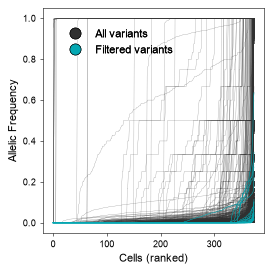

In [14]:
# Annotate vars in afm_raw
mt.pp.annotate_vars(afm_raw)

# Set colors
colors = {'All variants': '#303030', 'Filtered variants': '#05A8B3'}

# Plot allele frequency spectrum (before vs after filtering)
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.vars_AF_spectrum(afm_raw, ax=ax, color=colors['All variants'], alpha=.7, linewidth=.2)
mt.pl.vars_AF_spectrum(afm_raw[:,afm.var_names], ax=ax, color=colors['Filtered variants'], linewidth=.5, alpha=1)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We would also like to visualize the number of positive cells (+cells) vs the average number of UMIs supporting alternative allele basecalls across +cells, for each MT-SNV:

2026-09-21 10:09:17,290 - INFO - Re-annotate variants in afm


2026-09-21 10:09:17,361 - INFO - Re-annotate variants in afm


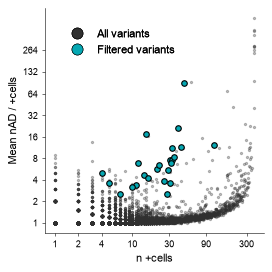

In [15]:
# Set xticks
xticks = [1, 2, 4, 10, 30, 90, 300, 1100]

# Plot number of cells vs mean alternative allele depth
fig, ax = plt.subplots(figsize=(3.5,3.5))
mt.pl.plot_ncells_nAD(afm_raw, ax=ax, xticks=xticks, color='#303030', s=2, alpha=.3, label='All variants')
mt.pl.plot_ncells_nAD(afm, ax=ax, color='#05A8B3', xticks=xticks, s=5, alpha=1, markeredgecolor='k', label='Filtered variants')
plu.format_ax(ax=ax, ylabel='Mean nAD / +cells', xlabel='n +cells', reduced_spines=True)
plu.add_legend(colors, ax=ax, loc='upper left', bbox_to_anchor=(0.05,.95), frameon=False)
fig.tight_layout()
plt.show()

We might also want to know where are these MT-SNVs distributed across the MT-genome

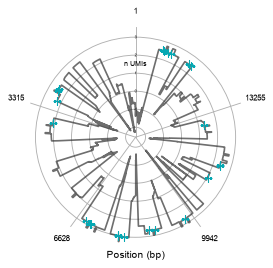

In [16]:
# Load coverage data
cov = mt.io.read_coverage(afm_raw, 'data_test/coverage.txt.gz', 'MDA_clones')

# Visualize MT genome coverage in polar coordinates, with MT-SNVs highlighted
fig, ax = plt.subplots(figsize=(3.5,3.5), subplot_kw={'projection': 'polar'})
mt.pl.MT_coverage_polar(
    cov, 
    var_subset=afm.var_names, ax=ax,
    yticks_size=4,
    kwargs_subset={'markersize': 8, 'c': '#05A8B3', 'label': 'Selected variants'}, 
    kwargs_main={'c': '#303030', 'linewidth': 1.5, 'alpha': .7, 'label': 'All positions'}
)
fig.tight_layout()
plt.show()

... which MT-gene harbour them

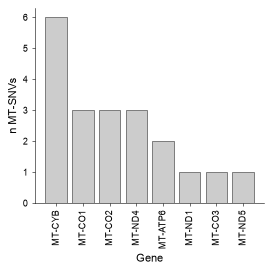

In [17]:
# Load MT-genes annotation
ref_df = mt.ut.load_mt_gene_annot()
df_plot = ref_df.query('mut in @afm.var_names')

# Plot variant distribution across MT genes
fig, ax = plt.subplots(figsize=(3.5,3.5))
plu.counts_plot(df_plot, 'Symbol', width=.8, ax=ax, color='#C0C0C0', edgecolor='k', with_label=False)
plu.format_ax(ax=ax, rotx=90, ylabel='n MT-SNVs', xlabel='Gene', reduced_spines=True)
fig.tight_layout()
plt.show()

... and which mutational signatures are they enriched for:

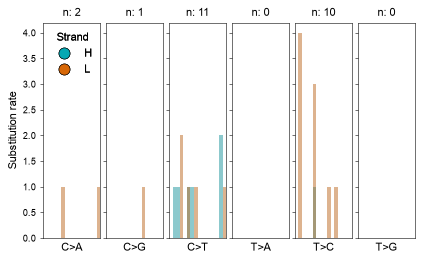

In [18]:
fig = mt.pl.mut_profile(afm.var_names, figsize=(6,3.5))
fig.tight_layout()
plt.show()

We would also like to visualize our characters and cell-cell distances in clustered heatmaps:

2026-09-21 10:09:20,070 - INFO - Compute tree from precomputed cell-cell distances...


2026-09-21 10:09:20,070 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-09-21 10:09:20,072 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


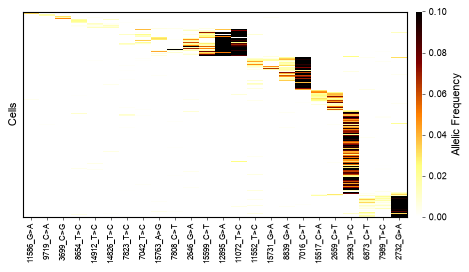

In [19]:
fig, ax = plt.subplots(figsize=(6,3.5))
mt.pl.heatmap_variants(afm, ax=ax, cmap='afmhot_r')
fig.tight_layout()
plt.show()

2026-09-21 10:09:20,317 - INFO - Compute tree from precomputed cell-cell distances...


2026-09-21 10:09:20,317 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-09-21 10:09:20,318 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


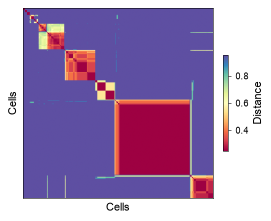

In [20]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
mt.pl.heatmap_distances(afm, ax=ax, cmap='Spectral')
fig.tight_layout()
plt.show()

### Lineage inference 
Before dealing with phylogeny inference diagnostics, we would also like to visualize if our ground-truth labels cluster in UMAP space.

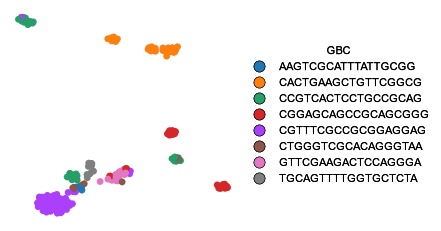

In [21]:
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = plu.create_palette(afm.obs, 'GBC', sc.pl.palettes.vega_10_scanpy)
mt.pl.draw_embedding(afm, feature='GBC', ax=ax, categorical_cmap=colors, legend=True, size=150)
plt.subplots_adjust(right=.7)
plt.show()

As we can see, to a great extent, lentiviral clones nicely cluster together.


Finally we would like to visualize our main downstream analysis product, our cell phylogeny and MiTo_clones:

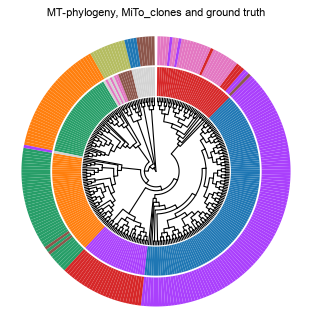

In [22]:
fig, ax = plt.subplots(figsize=(4, 4.2))
mt.pl.plot_tree(tree, annot=['MiTo_clone', 'GBC'], ax=ax, colorstrips={'width': 7.5})
ax.set_title('MT-phylogeny, MiTo_clones and ground truth')
fig.tight_layout()
plt.show()

## Outlook

More detailed tutorials, starting from the nf-MiTo INFER output (bootstrapped cell
phylogenies), will be available soon.
